---
title : "Dam Live"
---

In [ ]:
# initialiseer de (toolbox continu inzicht) modules
from pathlib import Path

from toolbox_continu_inzicht.base.config import Config
from toolbox_continu_inzicht.base.data_adapter import DataAdapter

## Inladen van belastingen FEWS HHNK

<details>
<summary>Configuratie</summary>

```yaml
GlobalVariables:
    rootdir: "data_sets/run_damlive"
    moments: [ 0, 24 ]
    calc_time: "2024-11-06 08:00:00"
    aquo_alias:
        H.meting: "WATHTE"
        WATHTE [m][NAP][OW]: "WATHTE"

    LoadsFews:
        host: "https://fews.hhnk.nl"
        port: 443
        region: "fewspiservice"
        version: "1.25"
        parameters: [ "H.meting", "WATHTE [m][NAP][OW]" ]

DataAdapter:
    default_options:
        csv:
            sep: ","
    locaties:
        type: csv
        path: "locations_fews.csv"
    waterstanden:
        type: csv
        path: "hidden_waterstanden_fews.csv"
    waterstanden_xml:
        type: xml_timeseries
        path: "waterstanden_fews.xml"
        parameter_mapping:
            WATHTE: H.meting
        location_mapping:
            MPN-N-24: BP

```

</details>

In [ ]:
config = Config(
    config_path=Path().cwd()
    / "data_sets"
    / "run_damlive"
    / "test_loads_fews_grondwater.yaml"
)
config.lees_config()

data_adapter = DataAdapter(config)

In [ ]:
from toolbox_continu_inzicht.loads.loads_fews.loads_fews import LoadsFews


loads_fews = LoadsFews(data_adapter=data_adapter)

In [ ]:
df_out = loads_fews.run(input="locaties", output="waterstanden_xml")

In [ ]:
data_adapter.input("waterstanden_xml")
file = data_adapter.config.data_adapters["waterstanden_xml"]["abs_path"]
with open(file) as f:
    xml_content = f.read()
# laast bovenste stukje van de xml zien
print(xml_content[:1300])

Voor het geval dat FEWS HHNK niet beschikbaar is, kan met het volgende bestand wel gerekend worden.
In het voorbeeld van FEWS hierboven is het een xml bestand maar elke tabel met meetreeks data kan gebruikt worden.

Bijvoorbeeld de csv:

```yaml
...
waterstanden:
    type: csv
    path: "waterstanden_fews.csv"
...
```

In [ ]:
data_adapter.input("waterstanden_xml")

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
df_waterstanden = data_adapter.input("waterstanden_xml")
for station in df_waterstanden["measurement_location_code"].unique():
    df_station = df_waterstanden[
        df_waterstanden["measurement_location_code"] == station
    ].copy()
    df_station.rename(columns={"value": station}, inplace=True)
    df_station.plot(x="date_time", y=station, ax=ax, legend=station, marker=".")

# loads to moments

Een deel van de data vanuit fews komt als kwartier data binnen, om dit naar uren te zetten wordt loads to moments gebruikt

In [ ]:
from toolbox_continu_inzicht.loads import LoadsToMoments

Voor dit voorbeeld doen we nu even 2 tijdstappen

In [ ]:
data_adapter.set_global_variable("moments", [i for i in range(0, 2, 1)])

In [ ]:
loads_to_moments = LoadsToMoments(data_adapter=data_adapter)
loads_to_moments.run(input="waterstanden_xml", output="waterstanden_xml_hourly")

In [ ]:
fig, ax = plt.subplots()
df_waterstanden = loads_to_moments.df_out
for station in df_waterstanden["measurement_location_code"].unique():
    df_station = df_waterstanden[
        df_waterstanden["measurement_location_code"] == station
    ].copy()
    df_station.rename(columns={"value": station}, inplace=True)
    df_station.plot(x="date_time", y=station, ax=ax, legend=station, marker=".")

## Runnen van dam_live

Voor dam live is een licentie van Deltares nodig.

Dit voorbeeld is gemaakt met een versie van damlive versie 26.1.0.7015.


In [96]:
# initialiseer de (toolbox continu inzicht) modules
from pathlib import Path

from toolbox_continu_inzicht.base.config import Config
from toolbox_continu_inzicht.base.data_adapter import DataAdapter


<details>
<summary> Configuratie</summary>

```yaml
GlobalVariables:
    rootdir: "data_sets/run_damlive"
    moments: [ 0, 24 ]
    calc_time: "2024-11-06 08:00:00"
    UpdateDamLive:
        DAMLIVE_FILE: 'WV2030_Purmer.damx'
        delete_output_folder: False

DataAdapter:
    default_options:
        csv:
            sep: ","
    waterstanden_xml_uur:
        type: xml_timeseries
        path: "waterstanden_fews_hourly.xml"
    parameters_bishop_csv:
        type: csv
        index: True
        path: "parameters_bishop.csv"
    parameters_uplift_csv:
        type: csv
        index: True
        path: "parameters_uplift.csv"
    output_file:
        type: csv
        path: test.csv

``` 
</details>


In [97]:
config = Config(
    config_path=Path().cwd() / "data_sets" / "run_damlive" / "run_damlive.yaml"
)
config.lees_config()

data_adapter = DataAdapter(config)

De benoemde waterstand metingen tabel moet mee gegeven worden

In [98]:
data_adapter.input("waterstanden_xml_uur")

,date_time,measurement_location_code,parameter_code,parameter_id,unit,value,measurement_location_id
0,2024-11-06 07:00:00+00:00,PB-288,H.meting,6115593,m,-2.148,4862447
1,2024-11-06 08:00:00+00:00,PB-288,H.meting,6115593,m,-2.145,4862447
2,2024-11-06 07:00:00+00:00,PB-286,H.meting,6115593,m,-0.428,9587229
3,2024-11-06 08:00:00+00:00,PB-286,H.meting,6115593,m,-0.428,9587229
4,2024-11-06 07:00:00+00:00,PB-289,H.meting,6115593,m,-3.093,9868118
5,2024-11-06 08:00:00+00:00,PB-289,H.meting,6115593,m,-3.091,9868118
6,2024-11-06 07:00:00+00:00,PB-287,H.meting,6115593,m,-1.364,219014
7,2024-11-06 08:00:00+00:00,PB-287,H.meting,6115593,m,-1.365,219014
8,2024-11-06 07:00:00+00:00,BP,H.meting,6115593,m,-0.488,7309800
9,2024-11-06 08:00:00+00:00,BP,H.meting,6115593,m,-0.486,7309800


En de parameters moeten ook nog worden mee geven, in dit geval rekenen we met bishop

Daarnaast moet in de `root_dir` een `{project_naam}.damx` bestand staan wat uitvoer is van een [`Dam stabiliteit`](https://publicwiki.deltares.nl/spaces/DAM/pages/166462239/Aanmaken+DAM+Live+project) berekening, en een map met de stix bestanden: `{project_naam}.geometries2D` waar in het `.damx` bestand naar wordt verwezen. 

In dit voorbeeld is de `project_naam`:  `WV2030_Purmer`. 

Het projectnaam moet meegeven worden in de opties, 

In [99]:
from toolbox_continu_inzicht.dam_live import UpdateDamLive

update_dam_live = UpdateDamLive(data_adapter=data_adapter)

In [100]:
# om meer informatie terug te krijgen van DAMLIVE, kan de logging level op INFO worden gezet.
update_dam_live.data_adapter.set_global_variable("logging", {"level": "INFO"})
update_dam_live.data_adapter.init_logging(re_initialize=True)

Dit duurt ca 2 min voor 2 tijdstappen: 

In [ ]:
update_dam_live.run(
    input=["waterstanden_xml_uur", "parameters_bishop_csv"], output="output_file"
)

In [101]:
df_output_damlive = update_dam_live.data_adapter.input("output_file")
df_output_damlive.head(5)

,Unnamed: 0,date_time,measurement_location_code,parameter_code,parameter_id,unit,value,measurement_location_id
0,0,2024-11-06 06:00:00+00:00,PU0013_87074-1_DWP001,StabilityInsideFactor,9309137,m,1.047054,5733664
1,1,2024-11-06 07:00:00+00:00,PU0013_87074-1_DWP001,StabilityInsideFactor,9309137,m,0.672593,5733664
2,2,2024-11-06 06:00:00+00:00,PU0021_87074-1_DWP002,StabilityInsideFactor,9309137,m,0.763164,3981444
3,3,2024-11-06 07:00:00+00:00,PU0021_87074-1_DWP002,StabilityInsideFactor,9309137,m,0.763183,3981444
4,4,2024-11-06 06:00:00+00:00,PU0030_87074-1_DWP003,StabilityInsideFactor,9309137,m,0.773453,5796962


## Verwerken van figuur data

Nu de berekening klaar is kunnen we de bestanden uitpakken. 

Mocht je problemen hebben met het uitpakken van de bestanden, kan het door de maximale pad naam lengthe van windows komen. De namen van de DamLive bestanden zijn vrij lang. 
Zie deze [gist](https://gist.github.com/leodutra/a25bc1f51e8779943df0a95d5a4839d1#windows-11) voor een oplossing

In [102]:
update_dam_live.unzip_damlive_results()

In [103]:
from toolbox_continu_inzicht.dam_live import CombineDamLiveResults

In [104]:
config = Config(
    config_path=Path().cwd()
    / "data_sets"
    / "run_damlive"
    / "dam_live_parse_config.yaml"
)
config.lees_config()

data_adapter = DataAdapter(config)

In [105]:
# na het uitpakken slaan we de resulterende bestandsnamen op, deze kunnen we hier weer inlezen
# dit is een voorbeeld specifiek voor deze configuratie en je paden, daarom is het niet in de functie verwerkt.
unziped_dirs = [
    str(path).split("development_notebooks\\dam_live\\")[1]
    for path in update_dam_live.lst_unzipped_damlive_results
]
# uit de bestands namen halen we de locatie en tijdstap, hier koppelen we vervolgens weer met de output dataframe
loc_time = [
    (fname.split("\\")[-1].split(".")[0], fname.split("\\")[-1].split(".")[-1])
    for fname in unziped_dirs
]
print(f"unzipped {len(unziped_dirs)} dirs")
unziped_dirs[:5]

unzipped 33 dirs


['data_sets\\run_damlive\\WV2030_Purmer.Calc\\Stability\\Bishop\\PU0013_87074-1_DWP001.0.2024-11-06T07',
 'data_sets\\run_damlive\\WV2030_Purmer.Calc\\Stability\\Bishop\\PU0013_87074-1_DWP001.0.2024-11-06T07',
 'data_sets\\run_damlive\\WV2030_Purmer.Calc\\Stability\\Bishop\\PU0013_87074-1_DWP001.1.2024-11-06T08',
 'data_sets\\run_damlive\\WV2030_Purmer.Calc\\Stability\\Bishop\\PU0021_87074-1_DWP002.0.2024-11-06T07',
 'data_sets\\run_damlive\\WV2030_Purmer.Calc\\Stability\\Bishop\\PU0021_87074-1_DWP002.1.2024-11-06T08']

We kunnen nu een van de resultaten bekijken:

In [106]:
run_index = 0
config.global_variables["rootdir"] = unziped_dirs[run_index]

In [107]:
combine_damlive_results = CombineDamLiveResults(data_adapter)

In [108]:
combine_damlive_results.run(
    input=[
        "scenario",
        "geometries",
        "soils",
        "soillayers",
        "waternets",
        "calculationsettings",
    ],
    output=["merge_soil", "merge_waternet", "merge_calculations"],
)
stage_id = list(combine_damlive_results.df_merged_soils.stage_id.unique())

De DamLive .stix resultaten kunnen we koppelen and het timeseries output bestand met locatie en tijd

In [109]:
import datetime

# in dit geval is de tijdzone van de output +1 uur, dus die wordt hier nog goed gezet voor het filteren
tz = datetime.timezone(datetime.timedelta(hours=1))
loc, time = loc_time[run_index]
date_time = df_output_damlive["date_time"].apply(
    lambda x: datetime.datetime.fromisoformat(x).astimezone(tz).strftime("%Y-%m-%dT%H")
)
df_corresponding_output = df_output_damlive[
    (df_output_damlive["measurement_location_code"] == loc) & (date_time == time)
]
df_corresponding_output

,Unnamed: 0,date_time,measurement_location_code,parameter_code,parameter_id,unit,value,measurement_location_id
0,0,2024-11-06 06:00:00+00:00,PU0013_87074-1_DWP001,StabilityInsideFactor,9309137,m,1.047054,5733664


En vervolgens plotten

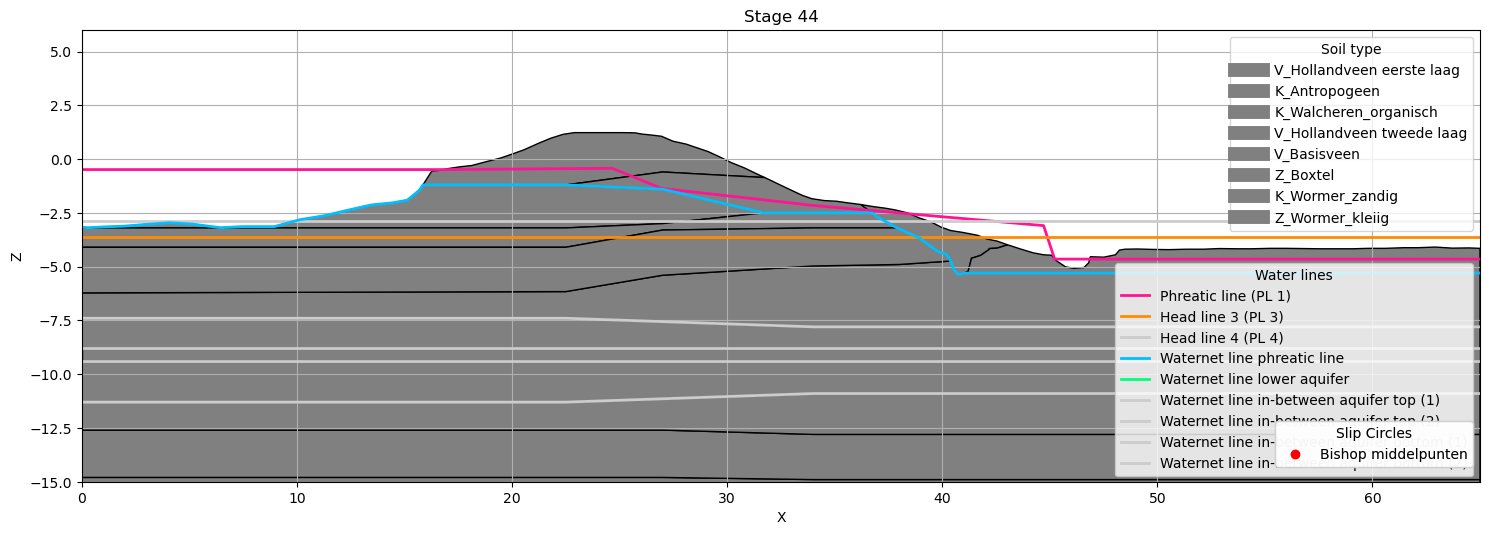

Stage 44 - Location: PU0013_87074-1_DWP001 - Time: 2024-11-06T07, StabilityInsideFactor: 1.047


In [110]:
import matplotlib.pyplot as plt

combine_damlive_results.plot_stage(
    stage_id=int(stage_id[0]),
    xlim=(0, 65),
    ylim=(-15, 6),
)
sf = df_corresponding_output.set_index("parameter_code").loc[
    "StabilityInsideFactor", "value"
]
print(
    f"Stage {stage_id[0]} - Location: {loc} - Time: {time}, StabilityInsideFactor: {sf:.3f}"
)

Als we alle bovenstaande stappen achter elkaar doen krijgen we een interactieve widget:

In [111]:
from ipywidgets import widgets


def make_widget(run_index):
    config.global_variables["rootdir"] = unziped_dirs[run_index]
    combine_damlive_results = CombineDamLiveResults(data_adapter)
    combine_damlive_results.run(
        input=[
            "scenario",
            "geometries",
            "soils",
            "soillayers",
            "waternets",
            "calculationsettings",
        ],
        output=["merge_soil", "merge_waternet", "merge_calculations"],
    )
    stage_id = list(combine_damlive_results.df_merged_soils.stage_id.unique())
    tz = datetime.timezone(datetime.timedelta(hours=1))
    loc, time = loc_time[run_index]
    date_time = df_output_damlive["date_time"].apply(
        lambda x: datetime.datetime.fromisoformat(x)
        .astimezone(tz)
        .strftime("%Y-%m-%dT%H")
    )
    df_corresponding_output = df_output_damlive[
        (df_output_damlive["measurement_location_code"] == loc) & (date_time == time)
    ]
    combine_damlive_results.plot_stage(
        stage_id=int(stage_id[0]),
        xlim=(0, 65),
        ylim=(-15, 6),
    )
    sf = df_corresponding_output.set_index("parameter_code").loc[
        "StabilityInsideFactor", "value"
    ]
    print(
        f"Stage {stage_id[0]} - Location: {loc} - Time: {time}, StabilityInsideFactor: {sf:.3f}"
    )


widgets.interact(
    make_widget,
    run_index=widgets.IntSlider(
        value=2,
        min=0,
        max=len(unziped_dirs) - 1,
        step=1,
        description="run_index",
        continuous_update=False,
    ),
);

interactive(children=(IntSlider(value=2, continuous_update=False, description='run_index', max=32), Output()),…

## Herhaal met UpliftVan

Dit duurt ca 5min voor 2 tijdstappen: 

In [112]:
update_dam_live.run(
    input=["waterstanden_xml_uur", "parameters_uplift_csv"], output="output_file"
)

In [113]:
update_dam_live.data_adapter.input("output_file").head(5)

,Unnamed: 0,date_time,measurement_location_code,parameter_code,parameter_id,unit,value,measurement_location_id
0,0,2024-11-06 06:00:00+00:00,PU0013_87074-1_DWP001,StabilityInsideFactor,9309137,m,1.047054,5733664
1,1,2024-11-06 07:00:00+00:00,PU0013_87074-1_DWP001,StabilityInsideFactor,9309137,m,0.672593,5733664
2,2,2024-11-06 06:00:00+00:00,PU0021_87074-1_DWP002,StabilityInsideFactor,9309137,m,0.763164,3981444
3,3,2024-11-06 07:00:00+00:00,PU0021_87074-1_DWP002,StabilityInsideFactor,9309137,m,0.763183,3981444
4,4,2024-11-06 06:00:00+00:00,PU0030_87074-1_DWP003,StabilityInsideFactor,9309137,m,0.773453,5796962


In [114]:
update_dam_live.unzip_damlive_results()
unziped_dirs = [
    str(path).split("development_notebooks\\dam_live\\")[1]
    for path in update_dam_live.lst_unzipped_damlive_results
]
loc_time = [
    (fname.split("\\")[-1].split(".")[0], fname.split("\\")[-1].split(".")[-1])
    for fname in unziped_dirs
]
print(f"unzipped {len(unziped_dirs)} dirs")
# dit is zowel bischop als uplift, voor nu alleen bischop gebruiken
unziped_dirs[33:38]

unzipped 65 dirs


['data_sets\\run_damlive\\WV2030_Purmer.Calc\\Stability\\UpliftVan\\PU0013_87074-1_DWP001.0.2024-11-06T07',
 'data_sets\\run_damlive\\WV2030_Purmer.Calc\\Stability\\UpliftVan\\PU0013_87074-1_DWP001.1.2024-11-06T08',
 'data_sets\\run_damlive\\WV2030_Purmer.Calc\\Stability\\UpliftVan\\PU0021_87074-1_DWP002.0.2024-11-06T07',
 'data_sets\\run_damlive\\WV2030_Purmer.Calc\\Stability\\UpliftVan\\PU0021_87074-1_DWP002.1.2024-11-06T08',
 'data_sets\\run_damlive\\WV2030_Purmer.Calc\\Stability\\UpliftVan\\PU0030_87074-1_DWP003.0.2024-11-06T07']

In [115]:
widgets.interact(
    make_widget,
    run_index=widgets.IntSlider(
        value=33,
        min=33,
        max=len(unziped_dirs) - 1,
        step=1,
        description="run_index",
        continuous_update=False,
    ),
);

interactive(children=(IntSlider(value=33, continuous_update=False, description='run_index', max=64, min=33), O…